# Genome Rewiring with Ledidi — Full Sequence

Optimises a genomic sequence so that the Akita-PyTorch model predicts a contact map
resembling that of a different genomic locus.

## Setup

In [1]:
import sys
import os

# Project root → gives access to utils/
PROJECT_ROOT = os.path.abspath("/home1/smaruj/akita_semifreddo")
sys.path.insert(0, PROJECT_ROOT)

# Akita model package
# sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_pytorch/"))
sys.path.append("/home1/smaruj/akita_pytorch/")

# Cloned ledidi repo (takes priority over any pip-installed version)
sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi/"))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

import torch

from ledidi import ledidi

from utils.model_utils import load_model
from utils.data_utils import from_upper_triu
from utils.plot_utils import plot_matrix

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Configuration

In [4]:
FOLD       = 0
INPUT_DIR  = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/genome_rewiring"
PLOTS_DIR = os.path.join(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))), "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

MODEL_WEIGHTS = (
    "/home1/smaruj/akita_pytorch/models/finetuned/mouse/"
    "Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
)

# Ledidi optimisation settings
LEDIDI_KWARGS = dict(
    batch_size         = 1,
    l                  = 0.05,
    max_iter           = 2000,
    early_stopping_iter= 2000,
    input_loss         = torch.nn.L1Loss(reduction="sum"),
    output_loss        = torch.nn.L1Loss(reduction="sum"),
    return_history     = True,
    verbose            = True,
)

## Load Model

In [5]:
model = load_model(MODEL_WEIGHTS, device)
print(model)

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

## Build Optimisation Table

Each row pairs a **source** locus (sequence to edit) with a **target** locus
(whose predicted map we want to match). Here the target is simply the
next window in fold order, with the last row wrapping around to the first.

In [6]:
df = pd.read_csv(f"{INPUT_DIR}/df_select_fold{FOLD}.tsv", sep="\t")

# Pair each window with the next one as its target (circular)
df["target_chrom"] = df["chrom"].shift(-1).fillna(df["chrom"].iloc[0])
df["target_start"] = df["start"].shift(-1).fillna(df["start"].iloc[0]).astype(int)
df["target_end"]   = df["end"].shift(-1).fillna(df["end"].iloc[0]).astype(int)

df.to_csv(
    f"{INPUT_DIR}/df_select_fold{FOLD}.tsv",
    sep="\t", index=False, header=True,
)

df.head()

,chrom,start,end,fold,target_chrom,target_start,target_end
0,chr5,63203328,64514048,fold0,chr3,138672128,139982848
1,chr3,138672128,139982848,fold0,chr5,43542528,44853248
2,chr5,43542528,44853248,fold0,chr3,115171328,116482048
3,chr3,115171328,116482048,fold0,chr7,61700096,63010816
4,chr7,61700096,63010816,fold0,chr4,141115392,142426112


## Run Ledidi Optimisation

In [7]:
# Restrict to a single example for this notebook
df_run = df.iloc[1:2]

results = []  # collect (row, generated_seq, history) for inspection below

for row in df_run.itertuples(index=False):
    chrom,  pred_start,   pred_end   = row.chrom,        row.start,        row.end
    tchrom, target_start, target_end = row.target_chrom, row.target_start, row.target_end

    print(f"\nOptimising  {chrom}:{pred_start}-{pred_end}")
    print(f"→ target    {tchrom}:{target_start}-{target_end}")

    X = torch.load(
        f"{INPUT_DIR}/ohe_X_fold{FOLD}/{chrom}_{pred_start}_{pred_end}_X.pt",
        weights_only=True, map_location=device,
    )  # (1, 4, seq_len)

    y_bar = torch.load(
        f"{INPUT_DIR}/genomic_targets_fold{FOLD}/{tchrom}_{target_start}_{target_end}_target.pt",
        weights_only=True, map_location=device,
    )  # (1, 1, 130305)

    generated_seq, history = ledidi(
        model, X, y_bar,
        device=device,
        **LEDIDI_KWARGS,
    )
    # generated_seq: (1, 4, seq_len)
    # history: dict with keys input_loss, output_loss, total_loss, edits, batch_size

    results.append((row, generated_seq, y_bar, history))


Optimising  chr3:138672128-139982848
→ target    chr5:43542528-44853248


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


iter=I	input_loss=0.0	output_loss=4.009e+04	total_loss=4.009e+04	time=0.0
iter=100	input_loss=1.445e+05	output_loss=6.906e+03	total_loss=1.413e+04	time=11.46
iter=200	input_loss=1.315e+05	output_loss=4.87e+03	total_loss=1.144e+04	time=11.39
iter=300	input_loss=1.483e+05	output_loss=3.733e+03	total_loss=1.115e+04	time=11.39
iter=400	input_loss=1.674e+05	output_loss=3.795e+03	total_loss=1.217e+04	time=11.4
iter=500	input_loss=1.853e+05	output_loss=5.656e+03	total_loss=1.492e+04	time=11.4
iter=600	input_loss=1.991e+05	output_loss=4.897e+03	total_loss=1.485e+04	time=11.4
iter=700	input_loss=2.126e+05	output_loss=4.032e+03	total_loss=1.466e+04	time=11.41
iter=800	input_loss=2.251e+05	output_loss=4.1e+03	total_loss=1.536e+04	time=11.41
iter=900	input_loss=2.351e+05	output_loss=4.008e+03	total_loss=1.576e+04	time=11.41
iter=1000	input_loss=2.399e+05	output_loss=4.53e+03	total_loss=1.653e+04	time=11.41
iter=1100	input_loss=2.428e+05	output_loss=4.304e+03	total_loss=1.645e+04	time=11.41
iter=12

## Inspect Results

In [8]:
row, generated_seq, target, history = results[0]
chrom, pred_start, pred_end = row.chrom, row.start, row.end
tag = f"{chrom}_{pred_start}_{pred_end}"

# Number of edited nucleotides
X_orig = torch.load(
    f"{INPUT_DIR}/ohe_X_fold{FOLD}/{chrom}_{pred_start}_{pred_end}_X.pt",
    weights_only=True, map_location="cpu",
)
n_edits = (generated_seq.cpu().argmax(1) != X_orig.argmax(1)).sum().item()
print(f"Edited nucleotides: {n_edits}")

Edited nucleotides: 124936


### Loss Curves

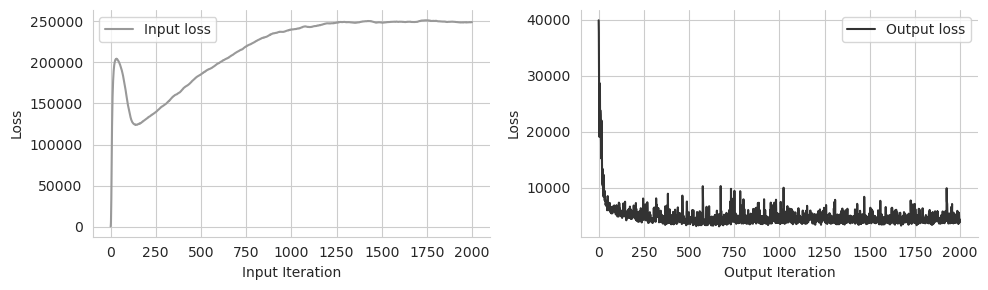

In [9]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(history["input_loss"],  color="0.6", label="Input loss")
axes[0].set_xlabel("Input Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=10)

axes[1].plot(history["output_loss"], color="0.2", label="Output loss")
axes[1].set_xlabel("Output Iteration")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=10)

sns.despine()
fig.tight_layout()
# fig.savefig(os.path.join(PLOTS_DIR, f"{tag}_loss_curves.svg"), format="svg")
plt.show()

### Predicted Contact Maps

In [10]:
model.eval()
with torch.no_grad():
    pred_edited   = model(generated_seq.to(device))  # (1, 1, 130305)
    pred_original = model(X_orig.to(device))          # (1, 1, 130305)

# Pearson R between edited prediction and target
r, _ = pearsonr(
    pred_edited.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
print(f"Pearson R (edited vs target): {r:.4f}")

Pearson R (edited vs target): 0.9813


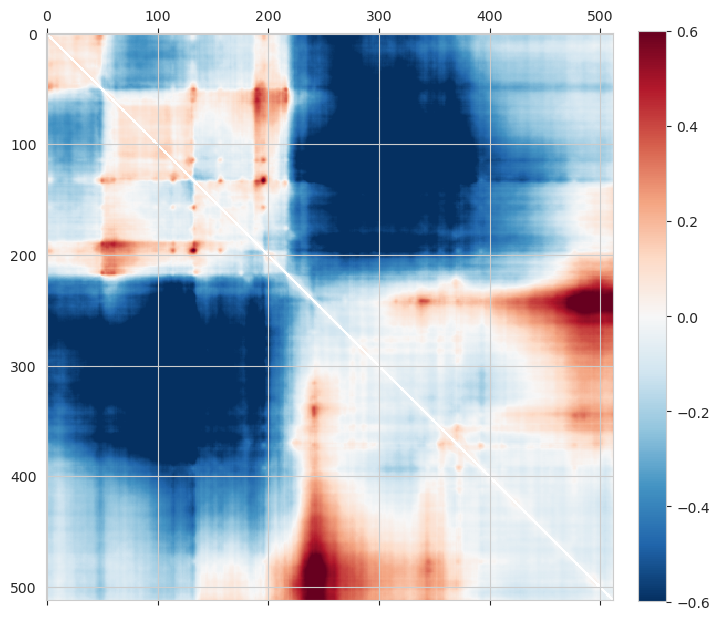

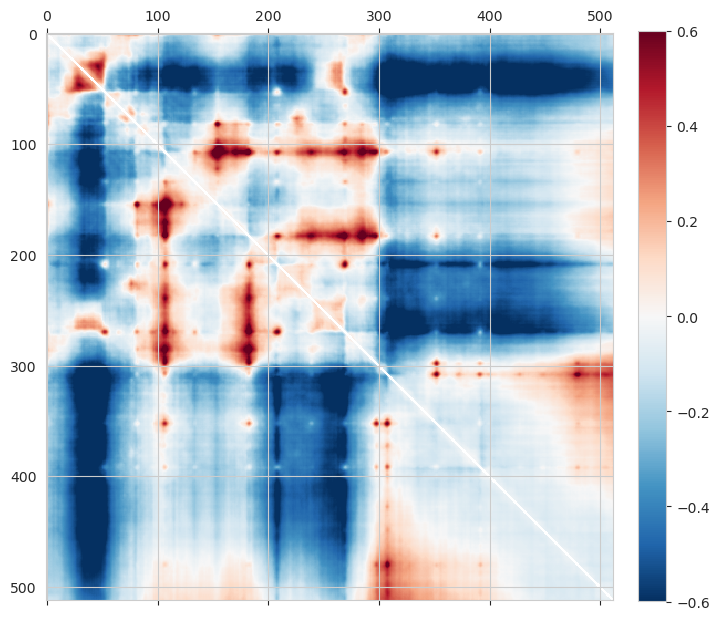

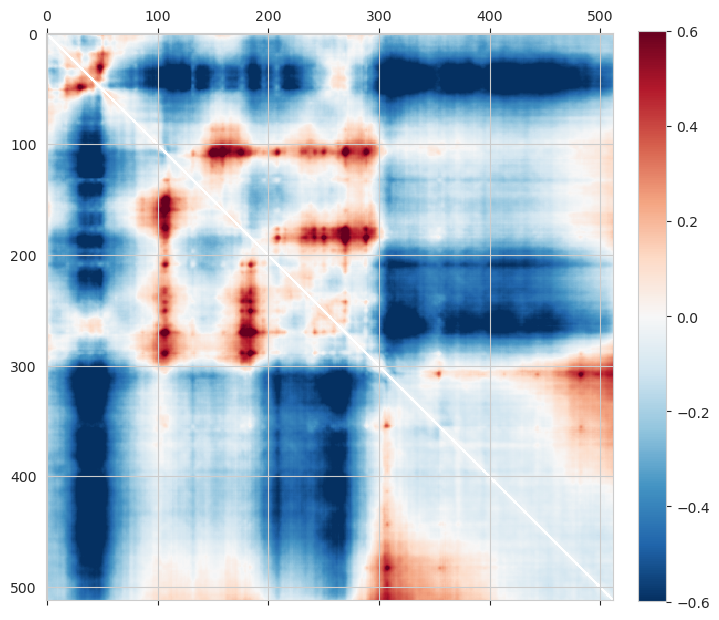

In [13]:
map_original = from_upper_triu(pred_original[0, 0, :], matrix_len=512, num_diags=2)
map_target   = from_upper_triu(target[0, 0, :],        matrix_len=512, num_diags=2)
map_edited   = from_upper_triu(pred_edited[0, 0, :],   matrix_len=512, num_diags=2)

plot_matrix(map_original, f"{PLOTS_DIR}/original_map.svg")
plot_matrix(map_target, f"{PLOTS_DIR}/target_map.svg")
plot_matrix(map_edited, f"{PLOTS_DIR}/optimized_map.svg")